Data saved to: C:\Users\vishw\OneDrive\Desktop\Explo\DANI\training-runs\00004-stylegan2-panda-gpus1-batch8-d_pos-first-noise_sd-0.5-target0.45-ada_kimg100-brand_new_run_numbered\compiled_metrics.csv



,Snapshot_Tick,FID,IS,KID
0,0,329.369289,5.300882,0.307457
1,1,63.525636,1.230550,0.051886
2,2,12.139771,1.008379,0.003014
3,3,10.553825,1.007229,0.001650
4,4,9.707331,1.006780,0.001138
5,5,9.533498,1.006692,0.001269
6,6,9.272043,1.006830,0.001043
7,7,9.852901,1.007900,0.001643
8,8,9.360287,1.007619,0.001005
9,9,9.052464,1.007797,0.000728


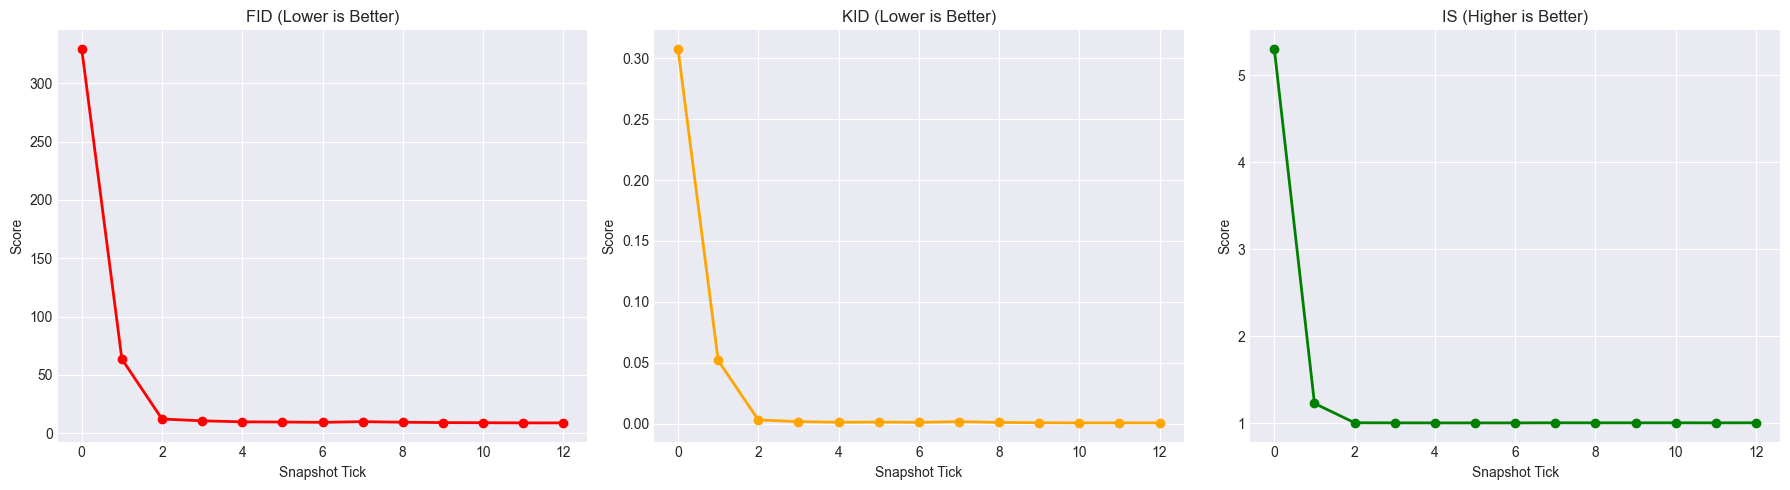

In [1]:
import os
import glob
import json
import pandas as pd
import matplotlib.pyplot as plt

import sys
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))


run_dir = os.path.join(BASE_DIR, "src", "DANI", "training-runs", "00004-stylegan2-panda-gpus1-batch8-d_pos-first-noise_sd-0.5-target0.45-ada_kimg100-brand_new_run_numbered")
jsonl_files = glob.glob(os.path.join(run_dir, "metric-*.jsonl"))

data_by_tick = {}

for j_file in jsonl_files:
    with open(j_file, 'r') as f:
        for line in f:
            if line.strip():
                try:
                    data = json.loads(line)
                    pkl_name = data.get("snapshot_pkl", "")
                    tick = int(pkl_name.split('-')[-1].replace('.pkl', ''))
                    
                    if tick not in data_by_tick:
                        data_by_tick[tick] = {}
                        
                    metric = data.get("metric")
                    results = data.get("results", {})
                    
                    if metric == "is50k":
                        data_by_tick[tick]["IS"] = results.get("is50k_mean")
                    elif metric == "fid50k_full":
                        data_by_tick[tick]["FID"] = results.get("fid50k_full")
                    elif metric == "kid50k_full":
                        data_by_tick[tick]["KID"] = results.get("kid50k_full")
                        
                except Exception:
                    continue

df = pd.DataFrame.from_dict(data_by_tick, orient='index').reset_index()
df = df.rename(columns={'index': 'Snapshot_Tick'}).sort_values('Snapshot_Tick')

csv_path = os.path.join(run_dir, "compiled_metrics.csv")
df.to_csv(csv_path, index=False)
print(f"Data saved to: {csv_path}\n")
display(df)

# Plotting
plt.style.use('seaborn-v0_8-darkgrid')
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

if "FID" in df.columns:
    axes[0].plot(df['Snapshot_Tick'], df['FID'], marker='o', color='red', linewidth=2)
    axes[0].set_title('FID (Lower is Better)', fontsize=12)
    axes[0].set_xlabel('Snapshot Tick')
    axes[0].set_ylabel('Score')

if "KID" in df.columns:
    axes[1].plot(df['Snapshot_Tick'], df['KID'], marker='o', color='orange', linewidth=2)
    axes[1].set_title('KID (Lower is Better)', fontsize=12)
    axes[1].set_xlabel('Snapshot Tick')
    axes[1].set_ylabel('Score')

if "IS" in df.columns:
    axes[2].plot(df['Snapshot_Tick'], df['IS'], marker='o', color='green', linewidth=2)
    axes[2].set_title('IS (Higher is Better)', fontsize=12)
    axes[2].set_xlabel('Snapshot Tick')
    axes[2].set_ylabel('Score')

plt.tight_layout()
plt.show()